## Basic Thought
Imagine a retail company with hundreds/thousands of products.

Every day, it has to answer:

How much inventory should we keep for each product in the coming days/weeks?

>Too much inventory:

+ capital gets locked
+ storage costs increase
+ products may become obsolete
+ markdowns increase

>Too little inventory:

+ stockouts
+ lost sales
+ unhappy customers
+ lower revenue

So the actual business question becomes:

`“Can we predict future demand and convert those predictions into actionable inventory decisions?”`

### Business Objective

Develop a data-driven decision-support system that predicts product demand and recommends inventory actions to reduce stockout risk while avoiding unnecessary inventory accumulation.

`Primary stakeholder`

Retail inventory / supply-chain manager.

`Decision`

How much inventory should be maintained/reordered?

`Prediction target`

Future product demand.

The project should:

+ produce reliable demand forecasts;
+ outperform a simple baseline;
+ identify inventory risk;
+ convert predictions into actionable recommendations;
+ quantify business impact.

That is business-first Data Science.

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
#pd.set_option("display.max_rows", 100)
#pd.set_option("display.max_colwidth", 100)

In [2]:
DATA_DIR = "../../Datasets_MLmodels/Chosen_Datasets/DemandForecasting/retail_store_inventory.csv"
OUTPUT_DIR = "../../outputs/Demand_Sales"

FIGURE_DIR = os.path.join(OUTPUT_DIR, "figures")

FORECAST_DIR = os.path.join(
    OUTPUT_DIR, "forecasts"
)

INVENTORY_DIR = os.path.join(
    OUTPUT_DIR, "inventory_recommendations"
)

EVALUATION_DIR = os.path.join(
    OUTPUT_DIR, "evaluation"
)

os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(FORECAST_DIR, exist_ok=True)
os.makedirs(INVENTORY_DIR, exist_ok=True)
os.makedirs(EVALUATION_DIR, exist_ok=True)

In [3]:
file_path = os.path.join(DATA_DIR)
df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (73100, 15)


In [4]:
display(df.head())

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [5]:
print("Columns:")
print(df.columns.tolist())

Columns:
['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing', 'Seasonality']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

In [7]:
if "Product ID" in df.columns:
    print("Unique products:", df["Product ID"].nunique())

Unique products: 20


In [8]:
if "Store ID" in df.columns:
    print("Unique stores:", df["Store ID"].nunique())

Unique stores: 5


In [9]:
if "Category" in df.columns:
    print("Unique categories:", df["Category"].nunique())

Unique categories: 5


In [10]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print("Minimum date:", df["Date"].min())
print("Maximum date:", df["Date"].max())

Minimum date: 2022-01-01 00:00:00
Maximum date: 2024-01-01 00:00:00


In [11]:
quality_report = pd.DataFrame({
    "data_type": df.dtypes,
    "missing_values": df.isnull().sum(),
    "missing_percentage": (df.isnull().mean() * 100),
    "unique_values": df.nunique()
})

display(quality_report.sort_values("missing_percentage", ascending=False))

,data_type,missing_values,missing_percentage,unique_values
Date,datetime64[ns],0,0.0,731
Store ID,object,0,0.0,5
Product ID,object,0,0.0,20
Category,object,0,0.0,5
Region,object,0,0.0,4
Inventory Level,int64,0,0.0,451
Units Sold,int64,0,0.0,498
Units Ordered,int64,0,0.0,181
Demand Forecast,float64,0,0.0,31608
Price,float64,0,0.0,8999


In [12]:
print("Duplicate rows:",df.duplicated().sum())
df = df.drop_duplicates().copy()

print("Shape after duplicate removal:", df.shape)

Duplicate rows: 0
Shape after duplicate removal: (73100, 15)


In [13]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical columns:")
print(numeric_columns)

categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Numerical columns:
['Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price', 'Discount', 'Holiday/Promotion', 'Competitor Pricing']
Categorical columns:
['Store ID', 'Product ID', 'Category', 'Region', 'Weather Condition', 'Seasonality']


In [14]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Date,73100,NaN,NaN,NaN,2022-12-31 23:59:59.999999744,2022-01-01 00:00:00,2022-07-02 00:00:00,2023-01-01 00:00:00,2023-07-03 00:00:00,2024-01-01 00:00:00,NaN
Store ID,73100,5,S001,14620,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product ID,73100,20,P0001,3655,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,73100,5,Furniture,14699,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,73100,4,East,18349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Inventory Level,73100.0,NaN,NaN,NaN,274.469877,50.0,162.0,273.0,387.0,500.0,129.949514
Units Sold,73100.0,NaN,NaN,NaN,136.46487,0.0,49.0,107.0,203.0,499.0,108.919406
Units Ordered,73100.0,NaN,NaN,NaN,110.004473,20.0,65.0,110.0,155.0,200.0,52.277448
Demand Forecast,73100.0,NaN,NaN,NaN,141.49472,-9.99,53.67,113.015,208.0525,518.55,109.254076
Price,73100.0,NaN,NaN,NaN,55.135108,10.0,32.65,55.05,77.86,100.0,26.021945


In [15]:
for column in df.columns:
    print(column)

Date
Store ID
Product ID
Category
Region
Inventory Level
Units Sold
Units Ordered
Demand Forecast
Price
Discount
Weather Condition
Holiday/Promotion
Competitor Pricing
Seasonality


In [16]:
print(df["Units Sold"].describe())

count    73100.000000
mean       136.464870
std        108.919406
min          0.000000
25%         49.000000
50%        107.000000
75%        203.000000
max        499.000000
Name: Units Sold, dtype: float64


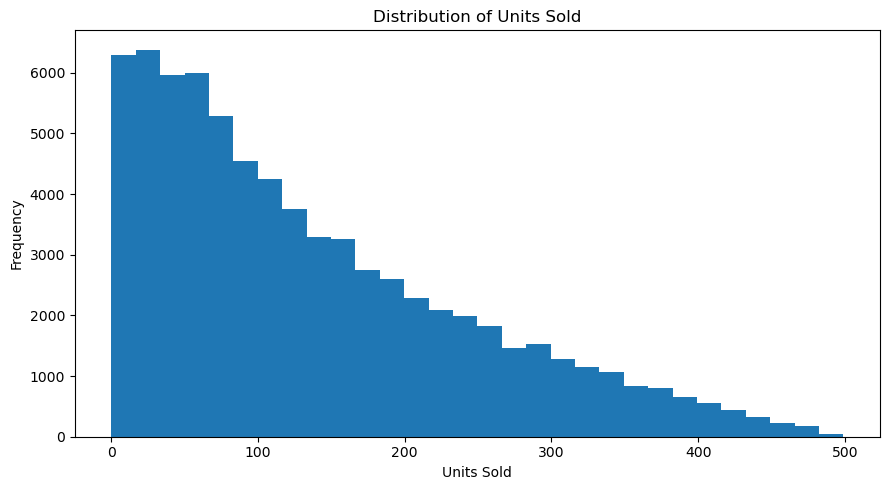

In [17]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["Units Sold"],
    bins=30
)
plt.title("Distribution of Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(os.path.join(FIGURE_DIR, "units_sold_distribution.png"), dpi=300)

plt.show()

In [18]:
if "Date" in df.columns and "Units Sold" in df.columns:

    daily_demand = (df.groupby("Date")["Units Sold"].sum().reset_index())
    display(daily_demand.head())

,Date,Units Sold
0,2022-01-01,14484
1,2022-01-02,13415
2,2022-01-03,13681
3,2022-01-04,14084
4,2022-01-05,12572


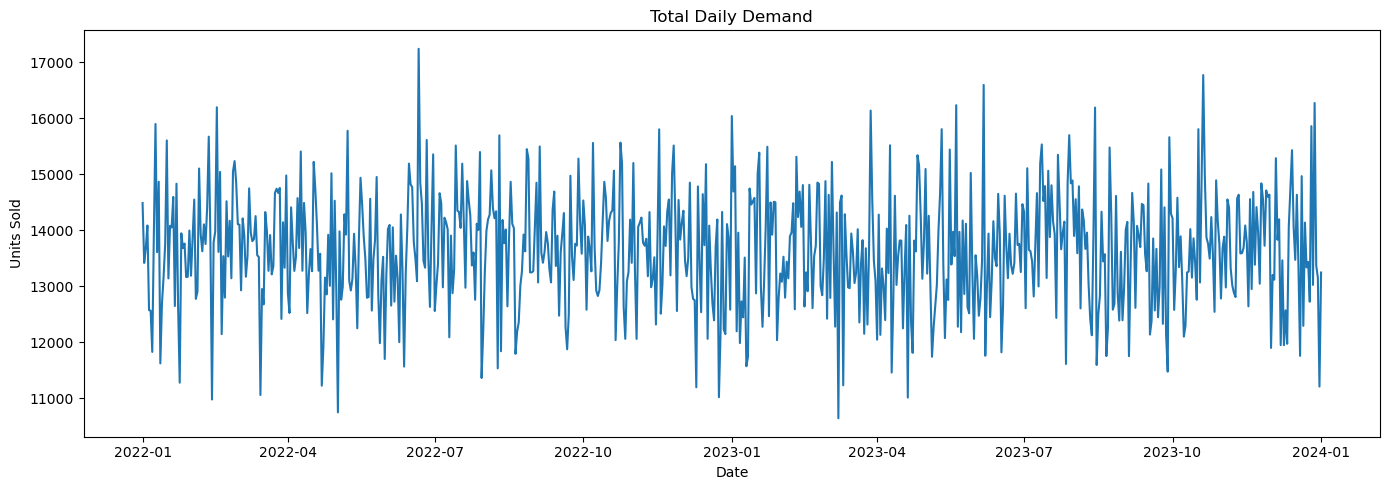

In [19]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_demand["Date"],
    daily_demand["Units Sold"]
)

plt.title("Total Daily Demand")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.tight_layout()

plt.savefig(os.path.join(FIGURE_DIR,"daily_demand_trend.png"), dpi=300)

plt.show()

In [20]:
df["YearMonth"] = (df["Date"].dt.to_period("M"))

monthly_demand = (df.groupby("YearMonth")["Units Sold"].sum().reset_index())
monthly_demand["YearMonth"] = (monthly_demand["YearMonth"].astype(str))

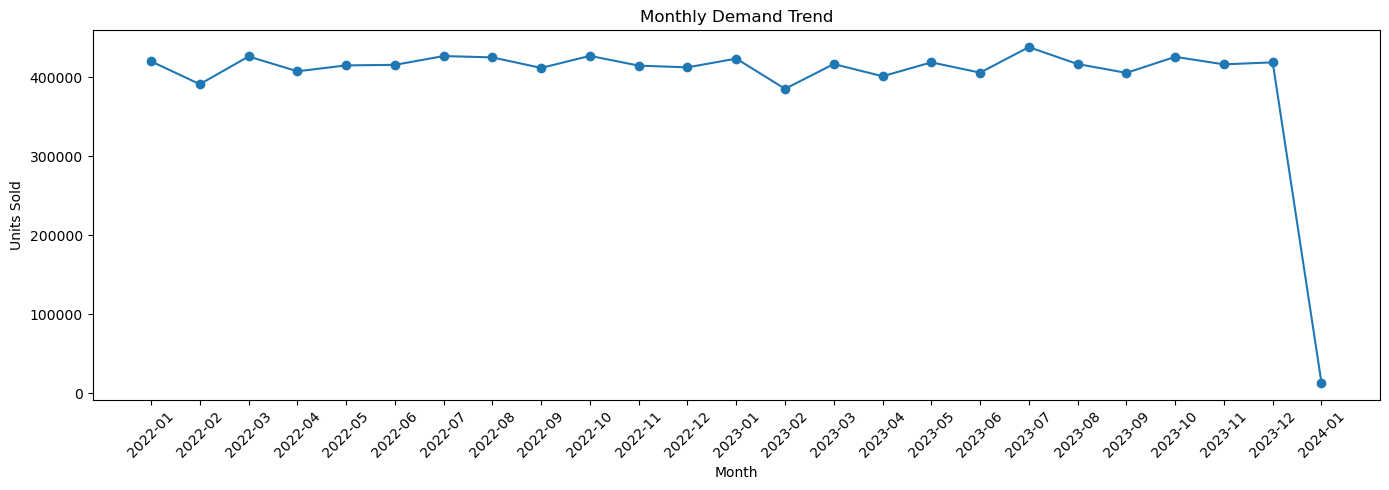

In [21]:
plt.figure(figsize=(14, 5))

plt.plot(
    monthly_demand["YearMonth"],
    monthly_demand["Units Sold"],
    marker="o"
)

plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Units Sold")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(os.path.join(FIGURE_DIR,"monthly_demand_trend.png"), dpi=300)

plt.show()

In [22]:
category_demand = (
    df.groupby("Category")["Units Sold"].sum().sort_values(ascending=False)
    )
display(category_demand)

Category
Furniture      2025017
Groceries      2000482
Clothing       1999166
Toys           1990485
Electronics    1960432
Name: Units Sold, dtype: int64

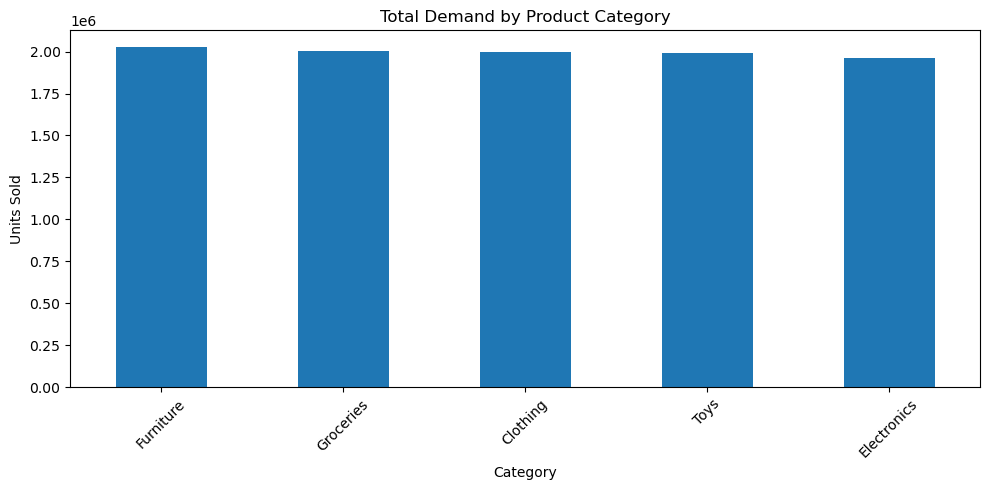

In [23]:
plt.figure(figsize=(10, 5))

category_demand.plot(
    kind="bar"
)

plt.title("Total Demand by Product Category")
plt.xlabel("Category")
plt.ylabel("Units Sold")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(os.path.join(FIGURE_DIR,"category_demand.png"), dpi=300)

plt.show()

In [24]:
inventory_columns = [
    column
    for column in df.columns
    if "inventory" in column.lower()
]

print("Inventory-related columns:", inventory_columns)
print("======================")
print(df["Inventory Level"].describe())

Inventory-related columns: ['Inventory Level']
count    73100.000000
mean       274.469877
std        129.949514
min         50.000000
25%        162.000000
50%        273.000000
75%        387.000000
max        500.000000
Name: Inventory Level, dtype: float64


In [25]:
inventory_demand = (df[["Inventory Level", "Units Sold"]].corr())
display(inventory_demand)

,Inventory Level,Units Sold
Inventory Level,1.000000,0.589995
Units Sold,0.589995,1.000000


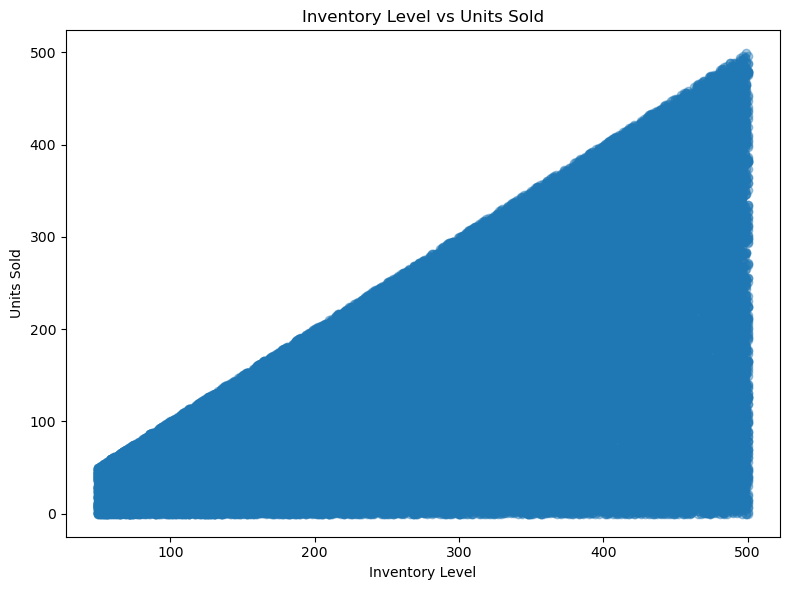

In [26]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Inventory Level"],
    df["Units Sold"],
    alpha=0.4
)

plt.title("Inventory Level vs Units Sold")
plt.xlabel("Inventory Level")
plt.ylabel("Units Sold")

plt.tight_layout()

plt.savefig(os.path.join(FIGURE_DIR, "inventory_vs_demand.png"), dpi=300)

plt.show()

In [27]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["WeekOfYear"] = (
    df["Date"].dt.isocalendar().week.astype(int)
)
df["Quarter"] = df["Date"].dt.quarter

In [28]:
sort_columns = [
    column
    for column in ["Store ID", "Product ID", "Date"]
    if column in df.columns
]

df = df.sort_values(sort_columns).copy()

In [29]:
group_columns = [
    column
    for column in ["Store ID", "Product ID"]
    if column in df.columns
]
if group_columns:
    df["Lag_1"] = (df.groupby(group_columns)["Units Sold"].shift(1))
    df["Lag_7"] = (df.groupby(group_columns)["Units Sold"].shift(7))
    df["Lag_14"] = (df.groupby(group_columns)["Units Sold"].shift(14))

In [30]:
if group_columns:
    df["Rolling_Mean_7"] = (df.groupby(group_columns)["Units Sold"].transform(lambda x:x.shift(1).rolling(7).mean()))
    df["Rolling_Std_7"] = (df.groupby(group_columns)["Units Sold"].transform(lambda x:x.shift(1).rolling(7).std()))

In [31]:
model_df = df.dropna(
    subset=["Lag_1", "Lag_7", "Lag_14", "Rolling_Mean_7", "Rolling_Std_7"]).copy()

print("Rows available for modelling:", len(model_df))

Rows available for modelling: 71700


In [32]:
TARGET = "Units Sold"

feature_candidates = [
    "Inventory Level", "Price", "Discount", "Weather Condition", "Holiday/Promotion", "Competitor Pricing", "Seasonality",
      "Year", "Month", "DayOfWeek", "WeekOfYear", "Quarter", "Lag_1", "Lag_7", "Lag_14", "Rolling_Mean_7", "Rolling_Std_7"
]

features = [
    column
    for column in feature_candidates
    if column in model_df.columns
]

print("Features:", features)

Features: ['Inventory Level', 'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing', 'Seasonality', 'Year', 'Month', 'DayOfWeek', 'WeekOfYear', 'Quarter', 'Lag_1', 'Lag_7', 'Lag_14', 'Rolling_Mean_7', 'Rolling_Std_7']


In [33]:
model_df = model_df.sort_values("Date").copy()

split_date = model_df["Date"].quantile(
    0.80
)

train_df = model_df[
    model_df["Date"] <= split_date].copy()

test_df = model_df[
    model_df["Date"] > split_date].copy()

print(f"Testing period: {test_df["Date"].min()} to {test_df["Date"].max()}")
print("Testing period:", test_df["Date"].min(), "to", test_df["Date"].max())

Testing period: 2023-08-12 00:00:00 to 2024-01-01 00:00:00
Testing period: 2023-08-12 00:00:00 to 2024-01-01 00:00:00


In [34]:
categorical_features = [
    column
    for column in [
        "Weather Condition", "Holiday/Promotion", "Seasonality", "Category", "Store ID", "Product ID"
    ]
    if column in features
]
numerical_features = [
    column
    for column in features
    if column not in categorical_features
]

print("Categorical:", categorical_features)
print("=========================================================================")
print("Numerical:", numerical_features)

Categorical: ['Weather Condition', 'Holiday/Promotion', 'Seasonality']
Numerical: ['Inventory Level', 'Price', 'Discount', 'Competitor Pricing', 'Year', 'Month', 'DayOfWeek', 'WeekOfYear', 'Quarter', 'Lag_1', 'Lag_7', 'Lag_14', 'Rolling_Mean_7', 'Rolling_Std_7']


In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numerical", "passthrough", numerical_features)
    ]
)

In [36]:
rf_model = Pipeline(
    steps=[("preprocessor", preprocessor),
        ("model", RandomForestRegressor( 
            n_estimators=200, max_depth=15, min_samples_leaf=2, random_state=42, n_jobs=-1)
        )
    ]
)

In [37]:
X_train = train_df[features]
y_train = train_df[TARGET]

X_test = test_df[features]
y_test = test_df[TARGET]

rf_model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [38]:
rf_predictions = rf_model.predict(
    X_test
)

rf_predictions = np.maximum(
    rf_predictions,
    0
)

In [39]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)
rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

rf_r2 = r2_score(y_test, rf_predictions)

print(f"Random Forest MAE: {rf_mae:.2f}")
print(f"Random Forest RMSE: {rf_rmse:.2f}")
print(f"Random Forest R²: {rf_r2:.4f}")

Random Forest MAE: 69.06
Random Forest RMSE: 88.34
Random Forest R²: 0.3337


In [40]:
hgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model",
         HistGradientBoostingRegressor(
             max_iter=300, learning_rate=0.05, max_leaf_nodes=31, l2_regularization=1.0, random_state=42)
        )
    ]
)

In [41]:
hgb_model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [42]:
hgb_predictions = hgb_model.predict(
    X_test
)

hgb_predictions = np.maximum(
    hgb_predictions,
    0
)

In [43]:
hgb_mae = mean_absolute_error(
    y_test,
    hgb_predictions
)
hgb_rmse = np.sqrt(
    mean_squared_error(y_test, hgb_predictions)
)

hgb_r2 = r2_score(y_test, hgb_predictions)

print(f"Gradient Boosting MAE: {hgb_mae:.2f}")
print(f"Gradient Boosting RMSE: {hgb_rmse:.2f}")
print(f"Gradient Boosting R²: {hgb_r2:.4f}")

Gradient Boosting MAE: 68.76
Gradient Boosting RMSE: 87.80
Gradient Boosting R²: 0.3418


In [44]:
model_comparison = pd.DataFrame({
    "Model": ["Random Forest", "HistGradientBoosting"],
    "MAE": [rf_mae, hgb_mae],
    "RMSE": [rf_rmse, hgb_rmse],
    "R2": [rf_r2, hgb_r2]
})

display(model_comparison.sort_values("RMSE"))

,Model,MAE,RMSE,R2
1,HistGradientBoosting,68.764566,87.804712,0.341753
0,Random Forest,69.063670,88.338479,0.333725


In [45]:
model_comparison.to_csv(
    os.path.join(
        EVALUATION_DIR, "model_comparison.csv"), index=False)

In [46]:
if hgb_rmse < rf_rmse:
    champion_model = hgb_model
    champion_name = "HistGradientBoosting"
    champion_predictions = hgb_predictions
else:
    champion_model = rf_model
    champion_name = "Random Forest"
    champion_predictions = rf_predictions

print("Champion model:", champion_name)

Champion model: HistGradientBoosting


In [47]:
comparison_df = test_df[["Date", TARGET]].copy()

comparison_df["Predicted_Demand"] = (champion_predictions)

comparison_df["Absolute_Error"] = (
    abs(
        comparison_df[TARGET] - comparison_df["Predicted_Demand"]
    )
)
display(comparison_df.head(20))

,Date,Units Sold,Predicted_Demand,Absolute_Error
58813,2023-08-12,173,150.448689,22.551311
58833,2023-08-12,21,57.088630,36.088630
58802,2023-08-12,41,183.455121,142.455121
58801,2023-08-12,46,178.258823,132.258823
58824,2023-08-12,199,198.272024,0.727976
58876,2023-08-12,85,82.500418,2.499582
58883,2023-08-12,70,68.540423,1.459577
58800,2023-08-12,46,73.845264,27.845264
58867,2023-08-12,157,120.701159,36.298841
58822,2023-08-12,2,74.508225,72.508225


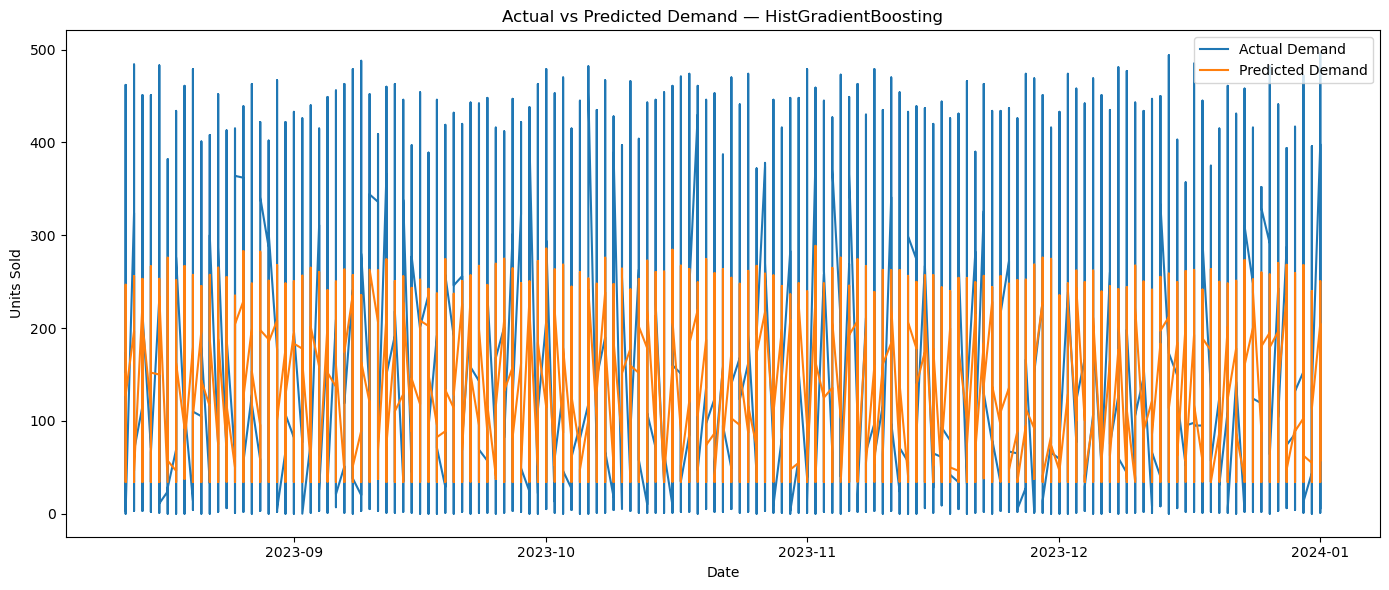

In [48]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison_df["Date"],
    comparison_df[TARGET],
    label="Actual Demand"
)
plt.plot(
    comparison_df["Date"],
    comparison_df["Predicted_Demand"],
    label="Predicted Demand"
)

plt.title(f"Actual vs Predicted Demand — {champion_name}")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.legend()

plt.tight_layout()

plt.savefig(os.path.join(FIGURE_DIR, "actual_vs_predicted_demand.png"), dpi=300)

plt.show()

In [49]:
forecast_output = test_df.copy()

forecast_output["Predicted_Demand"] = champion_predictions

forecast_output["Forecast_Error"] = (forecast_output[TARGET]-forecast_output["Predicted_Demand"])

forecast_output["Absolute_Error"] = abs(forecast_output["Forecast_Error"])

In [50]:
forecast_output.to_csv(
    os.path.join(
        FORECAST_DIR,"demand_forecasts.csv"), index=False)

In [51]:
forecast_output["Demand_Std"] = (
    forecast_output["Rolling_Std_7"].fillna(0))

In [52]:
LEAD_TIME_DAYS = 7
SERVICE_LEVEL_Z = 1.65

forecast_output["Safety_Stock"] = (
    SERVICE_LEVEL_Z * forecast_output["Demand_Std"] * np.sqrt(LEAD_TIME_DAYS)
)

In [53]:
forecast_output["Reorder_Point"] = (
    forecast_output["Predicted_Demand"] * LEAD_TIME_DAYS + forecast_output["Safety_Stock"]
)

In [54]:
forecast_output["Inventory_Position"] = (forecast_output["Inventory Level"])

forecast_output["Recommended_Order"] = (
    forecast_output["Reorder_Point"] - forecast_output["Inventory_Position"]
).clip(lower=0)

In [55]:
def classify_inventory_risk(row):
    inventory = row["Inventory_Position"]
    reorder_point = row["Reorder_Point"]

    if inventory < reorder_point * 0.50:
        return "Critical"
    elif inventory < reorder_point:
        return "Reorder"
    elif inventory > reorder_point * 1.50:
        return "Excess Inventory"
    else:
        return "Healthy"

In [56]:
forecast_output["Inventory_Risk"] = (
    forecast_output.apply(classify_inventory_risk, axis=1)
)

In [57]:
def business_action(risk):
    if risk == "Critical":
        return "Immediate Replenishment"
    elif risk == "Reorder":
        return "Place Reorder"
    elif risk == "Excess Inventory":
        return "Reduce / Delay Replenishment"
    else:
        return "Monitor"

In [58]:
forecast_output["Recommended_Action"] = (
    forecast_output["Inventory_Risk"].map(business_action))

In [59]:
recommendation_columns = [
    column
    for column in [
        "Date", "Store ID", "Product ID", "Category", "Inventory Level", "Units Sold", "Predicted_Demand",
        "Safety_Stock", "Reorder_Point", "Recommended_Order", "Inventory_Risk", "Recommended_Action"
    ]
    if column in forecast_output.columns
]

inventory_recommendations = (
    forecast_output[recommendation_columns].sort_values("Recommended_Order", ascending=False)
)
display(inventory_recommendations.head(20))

,Date,Store ID,Product ID,Category,Inventory Level,Units Sold,Predicted_Demand,Safety_Stock,Reorder_Point,Recommended_Order,Inventory_Risk,Recommended_Action
69751,2023-11-29,S003,P0012,Toys,482,85,253.027473,823.163706,2594.356018,2112.356018,Critical,Immediate Replenishment
64579,2023-10-08,S004,P0020,Groceries,498,104,275.861630,669.443995,2600.475405,2102.475405,Critical,Immediate Replenishment
71289,2023-12-14,S005,P0010,Toys,493,311,258.744399,777.621036,2588.831829,2095.831829,Critical,Immediate Replenishment
67610,2023-11-08,S001,P0011,Clothing,489,360,266.578850,709.207033,2575.258984,2086.258984,Critical,Immediate Replenishment
61949,2023-09-12,S003,P0010,Furniture,493,286,274.086790,653.313189,2571.920715,2078.920715,Critical,Immediate Replenishment
67525,2023-11-07,S002,P0006,Electronics,497,263,274.194908,655.996231,2575.360588,2078.360588,Critical,Immediate Replenishment
61449,2023-09-07,S003,P0010,Groceries,484,144,257.155554,758.592771,2558.681653,2074.681653,Critical,Immediate Replenishment
59628,2023-08-20,S002,P0009,Electronics,494,185,257.188686,766.993882,2567.314683,2073.314683,Critical,Immediate Replenishment
60291,2023-08-26,S005,P0012,Clothing,487,142,283.022481,564.065960,2545.223328,2058.223328,Critical,Immediate Replenishment
67865,2023-11-10,S004,P0006,Electronics,473,231,262.741680,676.452376,2515.644136,2042.644136,Critical,Immediate Replenishment


In [60]:
inventory_recommendations.to_csv(
    os.path.join(
        INVENTORY_DIR, "inventory_recommendations.csv"), index=False)

In [61]:
risk_summary = (forecast_output["Inventory_Risk"].value_counts().reset_index())
risk_summary.columns = ["Risk_Category", "Count"]

display(risk_summary)

,Risk_Category,Count
0,Critical,14300


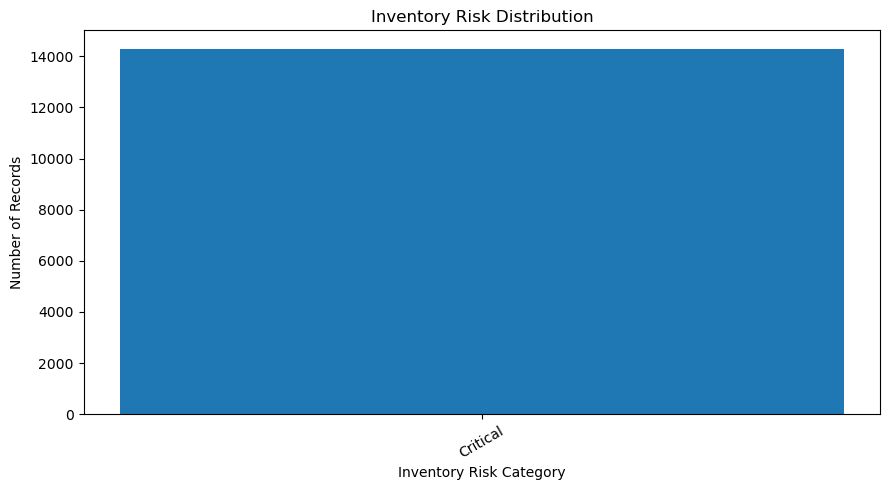

In [62]:
plt.figure(figsize=(9, 5))

plt.bar(
    risk_summary["Risk_Category"],
    risk_summary["Count"]
)

plt.title("Inventory Risk Distribution")
plt.xlabel("Inventory Risk Category")
plt.ylabel("Number of Records")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(os.path.join(FIGURE_DIR, "inventory_risk_distribution.png"), dpi=300)

plt.show()

In [63]:
priority_products = (
    forecast_output[forecast_output["Inventory_Risk"].isin(["Critical", "Reorder"])
    ].sort_values("Recommended_Order", ascending=False)
)

In [64]:
priority_columns = [
    column
    for column in [
        "Store ID", "Product ID", "Category", "Inventory Level", "Predicted_Demand", "Reorder_Point",
        "Recommended_Order", "Inventory_Risk", "Recommended_Action"
    ]
    if column in priority_products.columns
]

display(priority_products[priority_columns].head(25))

,Store ID,Product ID,Category,Inventory Level,Predicted_Demand,Reorder_Point,Recommended_Order,Inventory_Risk,Recommended_Action
69751,S003,P0012,Toys,482,253.027473,2594.356018,2112.356018,Critical,Immediate Replenishment
64579,S004,P0020,Groceries,498,275.861630,2600.475405,2102.475405,Critical,Immediate Replenishment
71289,S005,P0010,Toys,493,258.744399,2588.831829,2095.831829,Critical,Immediate Replenishment
67610,S001,P0011,Clothing,489,266.578850,2575.258984,2086.258984,Critical,Immediate Replenishment
61949,S003,P0010,Furniture,493,274.086790,2571.920715,2078.920715,Critical,Immediate Replenishment
67525,S002,P0006,Electronics,497,274.194908,2575.360588,2078.360588,Critical,Immediate Replenishment
61449,S003,P0010,Groceries,484,257.155554,2558.681653,2074.681653,Critical,Immediate Replenishment
59628,S002,P0009,Electronics,494,257.188686,2567.314683,2073.314683,Critical,Immediate Replenishment
60291,S005,P0012,Clothing,487,283.022481,2545.223328,2058.223328,Critical,Immediate Replenishment
67865,S004,P0006,Electronics,473,262.741680,2515.644136,2042.644136,Critical,Immediate Replenishment


In [65]:
priority_products[
    priority_columns].to_csv(os.path.join(INVENTORY_DIR, "priority_replenishment_list.csv"), index=False)

In [66]:
total_records = len(forecast_output)

critical_count = (forecast_output["Inventory_Risk"] == "Critical").sum()

reorder_count = (forecast_output["Inventory_Risk"] == "Reorder").sum()

excess_count = (forecast_output["Inventory_Risk"] == "Excess Inventory").sum()

healthy_count = (forecast_output["Inventory_Risk"] == "Healthy").sum()

total_recommended_units = (forecast_output["Recommended_Order"].sum())

print("========== EXECUTIVE KPIs ==========")

print(f"Forecast records analyzed: {total_records:,}")
print(f"Critical inventory records: {critical_count:,}")
print(f"Reorder records: {reorder_count:,}")
print(f"Excess inventory records: {excess_count:,}")
print(f"Healthy inventory records: {healthy_count:,}")
print(f"Recommended replenishment units: {total_recommended_units:,.0f}")
print(f"Champion model: {champion_name}")

========== EXECUTIVE KPIs ==========
Forecast records analyzed: 14,300
Critical inventory records: 14,300
Reorder records: 0
Excess inventory records: 0
Healthy inventory records: 0
Recommended replenishment units: 16,156,478
Champion model: HistGradientBoosting


In [67]:
executive_summary = pd.DataFrame({
    "Metric": ["Champion Model", "MAE", "RMSE", "R2", "Critical Inventory Records", "Reorder Records", 
               "Excess Inventory Records", "Healthy Inventory Records", "Recommended Replenishment Units"],
    "Value": [
        champion_name,
        mean_absolute_error(y_test, champion_predictions),
        np.sqrt(mean_squared_error(y_test, champion_predictions)),
        r2_score(
            y_test,
            champion_predictions
        ),
        critical_count,
        reorder_count,
        excess_count,
        healthy_count,
        total_recommended_units
    ]
})

display(executive_summary)

,Metric,Value
0,Champion Model,HistGradientBoosting
1,MAE,68.764566
2,RMSE,87.804712
3,R2,0.341753
4,Critical Inventory Records,14300
5,Reorder Records,0
6,Excess Inventory Records,0
7,Healthy Inventory Records,0
8,Recommended Replenishment Units,16156477.557617


In [68]:
executive_summary.to_csv(
    os.path.join(EVALUATION_DIR, "executive_summary.csv"), index=False)